In [1]:
import torch
import math
import matplotlib.pyplot as plt

from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.diffeomorphisms.vector.star import StarVectorDiffeomorphism

from src.distributions.stars.lq_norm import LqNormStarDistribution

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean


from src.radials.unimodal.lq_norm import LqNormRadial

In [2]:
alpha = 1.
q = 0.5

In [3]:
radial = LqNormRadial(2, q=q, alpha=alpha)

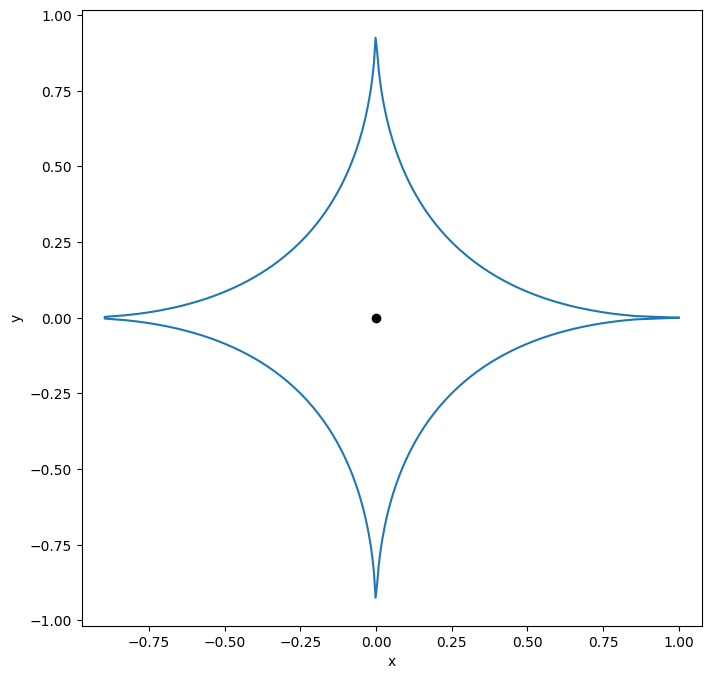

In [4]:
theta = torch.linspace(0, 2 * torch.pi, 1000)
circle = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)
star = radial(circle).unsqueeze(1) * circle 

plt.figure(figsize=(8, 8))
plt.plot(star[:, 0], star[:, 1], label="lq-norm radial")
plt.scatter(0, 0, color='black', label="origin")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()

In [5]:
dist = LqNormStarDistribution(2, q=q, alpha=alpha)

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


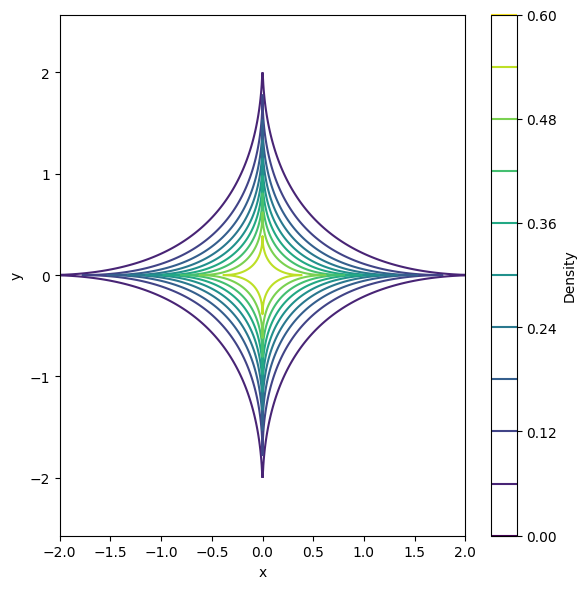

In [6]:
# plot density
n_points = 1001
x = torch.linspace(-2, 2, n_points)
y = torch.linspace(-2, 2, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs = torch.exp(dist.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

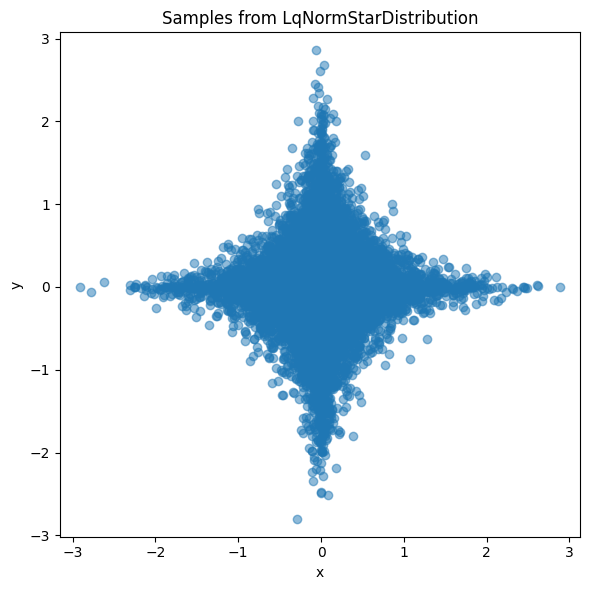

In [7]:
# sample from distribution and plot
n_samples = 10000
samples = dist.sample(n_samples) 
plt.figure(figsize=(6,6))
plt.scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title('Samples from LqNormStarDistribution')
plt.tight_layout()
plt.show()

Maximum log_prob: -1.5466 at alpha=1.09, q=0.46


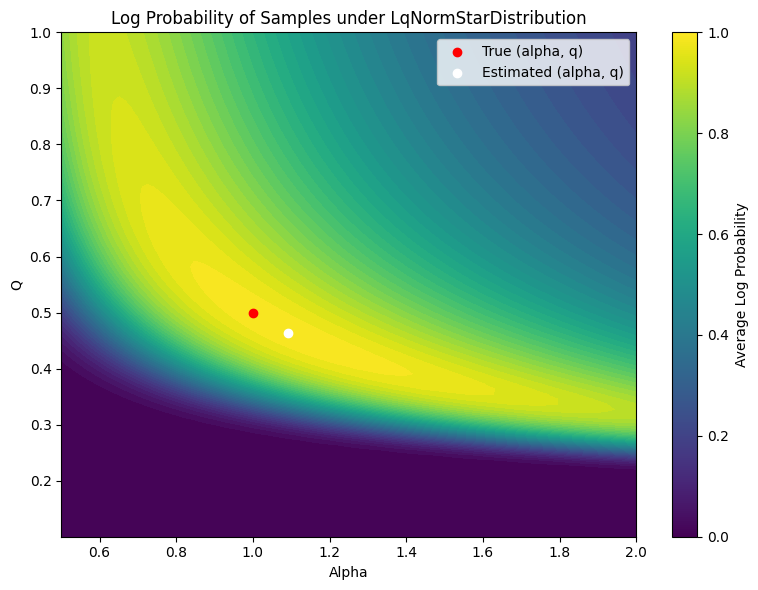

In [11]:
# now we want to retrieve alpha and q from the samples by fitting the distribution
alphas = torch.linspace(0.5, 2.0, 100)
qs = torch.linspace(0.1, 1, 100)

Alphas, Qs = torch.meshgrid(alphas, qs)
LogProbs = torch.zeros_like(Alphas)

alpha_max = alphas[0]
q_max = qs[0]
log_prob_max = -math.inf
for i, alpha_i in enumerate(alphas):
    for j, q_j in enumerate(qs):
        dist_ij = LqNormStarDistribution(2, q=q_j, alpha=alpha_i)
        log_prob_ij = dist_ij.log_prob(samples).mean().item() - 0.1 * (alpha_i - 1) ** 2
        LogProbs[i, j] = log_prob_ij 
        if log_prob_ij > log_prob_max:
            log_prob_max = log_prob_ij 
            alpha_max = alpha_i
            q_max = q_j

print(f"Maximum log_prob: {log_prob_max:.4f} at alpha={alpha_max:.2f}, q={q_max:.2f}")

plt.figure(figsize=(8, 6))
plt.contourf(Alphas.numpy(), Qs.numpy(), LogProbs.exp().numpy(), levels=50, cmap='viridis')
plt.scatter([alpha], [q], color='red', label='True (alpha, q)')
plt.scatter([alpha_max], [q_max], color='white', label='Estimated (alpha, q)')
plt.legend()
plt.colorbar(label='Average Log Probability')
plt.xlabel('Alpha')
plt.ylabel('Q')
plt.title('Log Probability of Samples under LqNormStarDistribution')
plt.tight_layout()
plt.show()

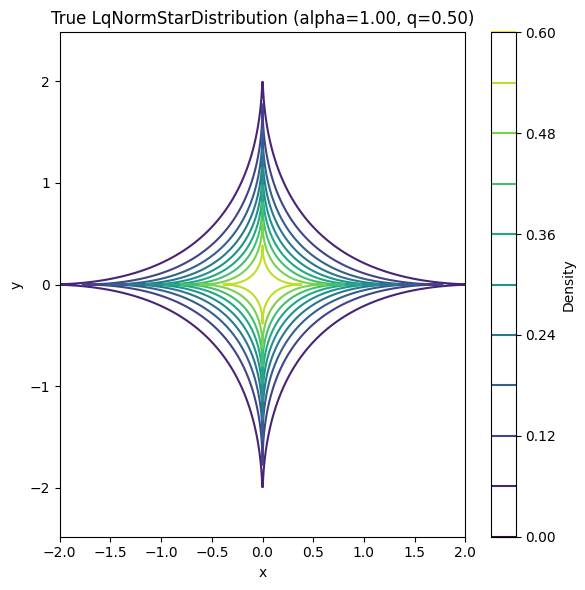

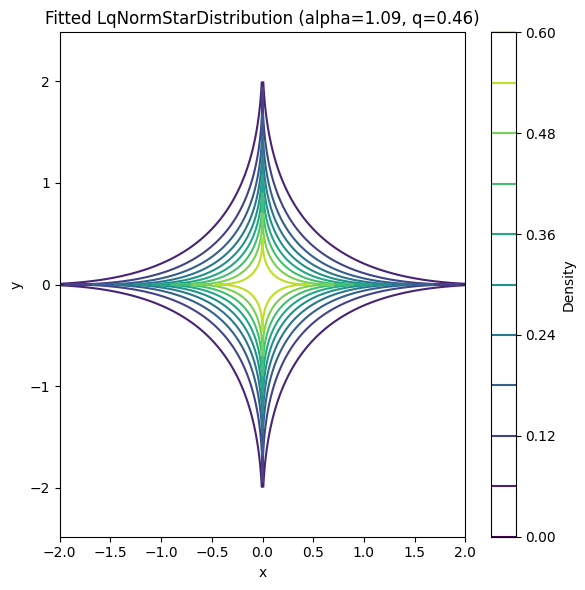

In [12]:
dist_max = LqNormStarDistribution(2, q=q_max, alpha=alpha_max)
log_probs_max = torch.exp(dist_max.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title(f'True LqNormStarDistribution (alpha={alpha:.2f}, q={q:.2f})')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_max.numpy(), levels=10, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title(f'Fitted LqNormStarDistribution (alpha={alpha_max:.2f}, q={q_max:.2f})')
plt.tight_layout()
plt.show()

In [10]:
# check normalization integrates to 1 by monte carlo from uniform samples
dim = 5
n_dist = LqNormStarDistribution(dim, q=q, alpha=alpha)
n_mc_samples = 10000000
range_min, range_max = -3.0, 3.0
mc_samples = (torch.rand(n_mc_samples, dim) - 0.5) * (range_max - range_min)  # uniform in [-3, 3]^dim
mc_log_probs = n_dist.log_prob(mc_samples)
mc_probs = torch.exp(mc_log_probs)
mc_integral = mc_probs.mean() * ((range_max - range_min) ** dim)  # area of bounding box
print(f'Monte Carlo integral estimate: {mc_integral.item()}')

Monte Carlo integral estimate: 1.2616004943847656
